In [1]:
!pip install xgboost

In [2]:
!pip install shap

In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
)

import xgboost as xgb
import joblib
import os

RANDOM_STATE = 42

In [5]:
# Reproduce the Part D cleaning steps needed to get patient_nbr aligned with train_clean_selected.csv
raw = pd.read_csv("../data/raw/diabetic_data.csv")
raw = raw.replace("?", np.nan)
raw = raw[raw["gender"] != "Unknown/Invalid"].copy()
raw["readmitted_30"] = (raw["readmitted"] == "<30").astype(int)

X_raw = raw.drop(columns=["readmitted_30"])
y_raw = raw["readmitted_30"]
groups_raw = raw["patient_nbr"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_raw, y_raw, groups=groups_raw))

patient_nbr_train = raw.iloc[train_idx]["patient_nbr"].reset_index(drop=True)

print("Reconstructed training patient_nbr array length:", len(patient_nbr_train))

Reconstructed training patient_nbr array length: 81526


In [6]:
# Load the actual feature-selected data and verify alignment
train_df = pd.read_csv("../data/processed/train_clean_selected.csv")
test_df = pd.read_csv("../data/processed/test_clean_selected.csv")

TARGET = "readmitted_30"

assert len(train_df) == len(patient_nbr_train), (
    "Row count mismatch — reconstructed split does not match train_clean_selected.csv. "
    "Check RANDOM_STATE and cleaning steps match 02_Data_Preprocessing.ipynb exactly."
)

# Sanity check: target values in the reconstructed order should match train_df's target
reconstructed_target = raw.iloc[train_idx][TARGET].reset_index(drop=True)
assert (reconstructed_target.values == train_df[TARGET].values).all(), (
    "Target mismatch — row order does not align. Do not proceed with grouped CV until this passes."
)

print("PASS: reconstructed patient_nbr aligns with train_clean_selected.csv row order.")
print("Unique patients in training set:", patient_nbr_train.nunique())


PASS: reconstructed patient_nbr aligns with train_clean_selected.csv row order.
Unique patients in training set: 57175


In [7]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
base_scale_pos_weight = neg / pos
print(f"Class counts -> negative: {neg}, positive: {pos}")
print(f"Rule-of-thumb scale_pos_weight: {base_scale_pos_weight:.3f}")


Class counts -> negative: 72359, positive: 9167
Rule-of-thumb scale_pos_weight: 7.893


In [8]:
param_distributions = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0],
    "scale_pos_weight": [
        base_scale_pos_weight * 0.5,
        base_scale_pos_weight * 0.75,
        base_scale_pos_weight,
        base_scale_pos_weight * 1.25,
    ],
}

base_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train, groups=patient_nbr_train)

print("Best PR-AUC (CV mean):", search.best_score_)
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best PR-AUC (CV mean): 0.19572007533094443
Best params:
  subsample: 0.8
  scale_pos_weight: 5.920066543034799
  reg_lambda: 2.0
  reg_alpha: 1.0
  n_estimators: 200
  min_child_weight: 7
  max_depth: 3
  learning_rate: 0.01
  gamma: 1.0
  colsample_bytree: 1.0


In [9]:
baseline_prauc = 0.1588  # from D021, XGBoost + class_weight, untuned, plain StratifiedKFold
tuned_prauc = search.best_score_

print(f"D021 baseline (untuned, ungrouped CV):  PR-AUC = {baseline_prauc:.4f}")
print(f"This search (tuned, grouped CV):        PR-AUC = {tuned_prauc:.4f}")
print(f"Difference: {tuned_prauc - baseline_prauc:+.4f}")
print()
print("Note for report: these two numbers are not perfectly comparable — this search used grouped CV")
print("(more conservative/realistic), the baseline used ungrouped CV. State this explicitly rather than")
print("presenting the raw delta as a clean before/after tuning effect.")


D021 baseline (untuned, ungrouped CV):  PR-AUC = 0.1588
This search (tuned, grouped CV):        PR-AUC = 0.1957
Difference: +0.0369

Note for report: these two numbers are not perfectly comparable — this search used grouped CV
(more conservative/realistic), the baseline used ungrouped CV. State this explicitly rather than
presenting the raw delta as a clean before/after tuning effect.


Early stopping selected n_estimators = 10 (ceiling was 1000)


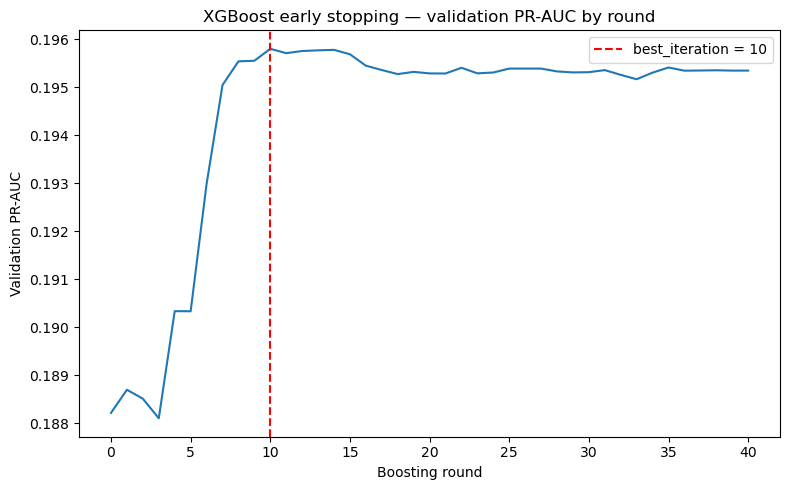

In [10]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
fit_idx, val_idx = next(gss.split(X_train, y_train, groups=patient_nbr_train))

X_fit, X_val = X_train.iloc[fit_idx], X_train.iloc[val_idx]
y_fit, y_val = y_train.iloc[fit_idx], y_train.iloc[val_idx]

best_params = search.best_params_.copy()
best_params.pop("n_estimators", None)  # let early stopping decide this

early_stop_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_estimators=1000,  # high ceiling; early stopping will cut this short
    early_stopping_rounds=30,
    **best_params,
)

early_stop_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

best_n_estimators = early_stop_model.best_iteration
print(f"Early stopping selected n_estimators = {best_n_estimators} (ceiling was 1000)")

results = early_stop_model.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["aucpr"])
plt.axvline(best_n_estimators, color="red", linestyle="--", label=f"best_iteration = {best_n_estimators}")
plt.xlabel("Boosting round")
plt.ylabel("Validation PR-AUC")
plt.title("XGBoost early stopping — validation PR-AUC by round")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# ---- Final model: adopting the alt configuration (see comparison above) ----
final_params = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "min_child_weight": 1,
    "gamma": 0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": base_scale_pos_weight,
    "n_estimators": early_stop_model.best_iteration,
}

final_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_params,
)

final_model.fit(X_train, y_train)
print("Final model (alt config) fitted on full training set.")
print("Final hyperparameters:", final_params)

Final model (alt config) fitted on full training set.
Final hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': np.float64(7.893422057379731), 'n_estimators': 10}


Threshold maximising F2 (recall-weighted): 0.4321
At this threshold -> precision: 0.1224, recall: 0.9148, F2: 0.3986


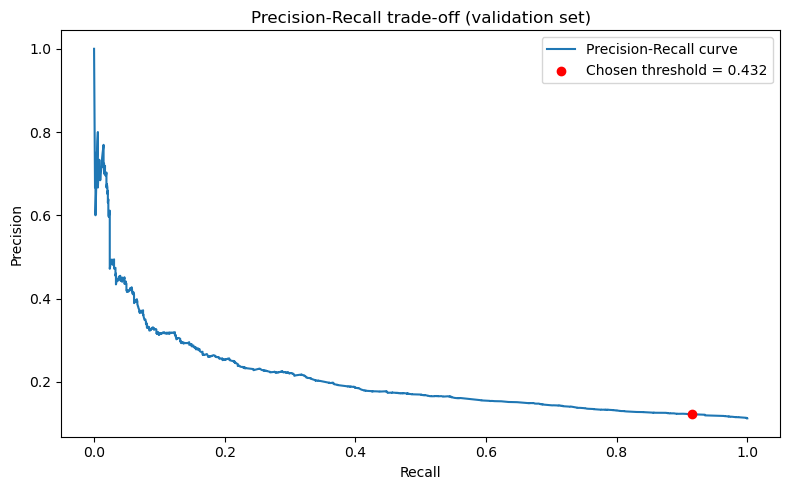

In [12]:
val_proba = final_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

# F2 score weights recall higher than precision (factor of 2) -- a defensible choice given the
# healthcare framing that false negatives (missed readmissions) are costlier than false positives.
beta = 2
f2_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-12)
best_idx = np.argmax(f2_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Threshold maximising F2 (recall-weighted): {best_threshold:.4f}")
print(f"At this threshold -> precision: {precisions[best_idx]:.4f}, recall: {recalls[best_idx]:.4f}, F2: {f2_scores[best_idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, label="Precision-Recall curve")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5,
            label=f"Chosen threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall trade-off (validation set)")
plt.legend()
plt.tight_layout()
plt.show()


--- Default threshold (0.5) ---
PR-AUC:    0.1936
ROC-AUC:   0.6297
Precision: 0.1654
Recall:    0.4808
F1:        0.2461

--- Tuned threshold (0.432) ---
PR-AUC:    0.1936
ROC-AUC:   0.6297
Precision: 0.1190
Recall:    0.9146
F1:        0.2106



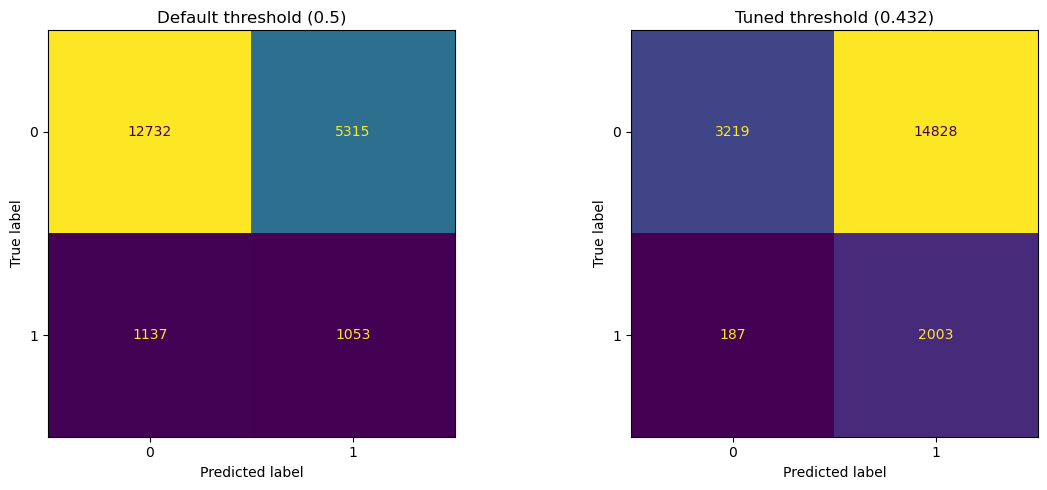

In [13]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_tuned = (test_proba >= best_threshold).astype(int)

def report_metrics(y_true, y_pred, y_proba, label):
    print(f"--- {label} ---")
    print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")
    print()

report_metrics(y_test, test_pred_default, test_proba, "Default threshold (0.5)")
report_metrics(y_test, test_pred_tuned, test_proba, f"Tuned threshold ({best_threshold:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_default)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Default threshold (0.5)")
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_tuned)).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Tuned threshold ({best_threshold:.3f})")
plt.tight_layout()
plt.show()

In [14]:
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
for t in [0.2, 0.3, 0.4, 0.449, 0.5, 0.6, 0.7]:
    pred = (val_proba >= t).astype(int)
    p = precision_score(y_val, pred, zero_division=0)
    r = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)
    print(f"{t:>10.3f} {p:>10.3f} {r:>10.3f} {f1:>10.3f}")

 Threshold  Precision     Recall         F1
     0.200      0.112      1.000      0.202
     0.300      0.112      1.000      0.202
     0.400      0.115      0.986      0.206
     0.449      0.126      0.864      0.219
     0.500      0.170      0.487      0.251
     0.600      0.317      0.124      0.178
     0.700      0.724      0.015      0.030


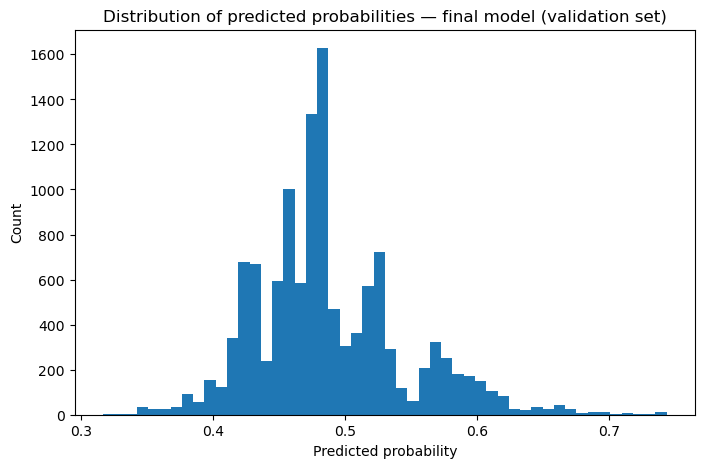

Min: 0.3164, Max: 0.7439, Mean: 0.4876


In [15]:
plt.figure(figsize=(8, 5))
plt.hist(val_proba, bins=50)
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities — final model (validation set)")
plt.show()

print(f"Min: {val_proba.min():.4f}, Max: {val_proba.max():.4f}, Mean: {val_proba.mean():.4f}")

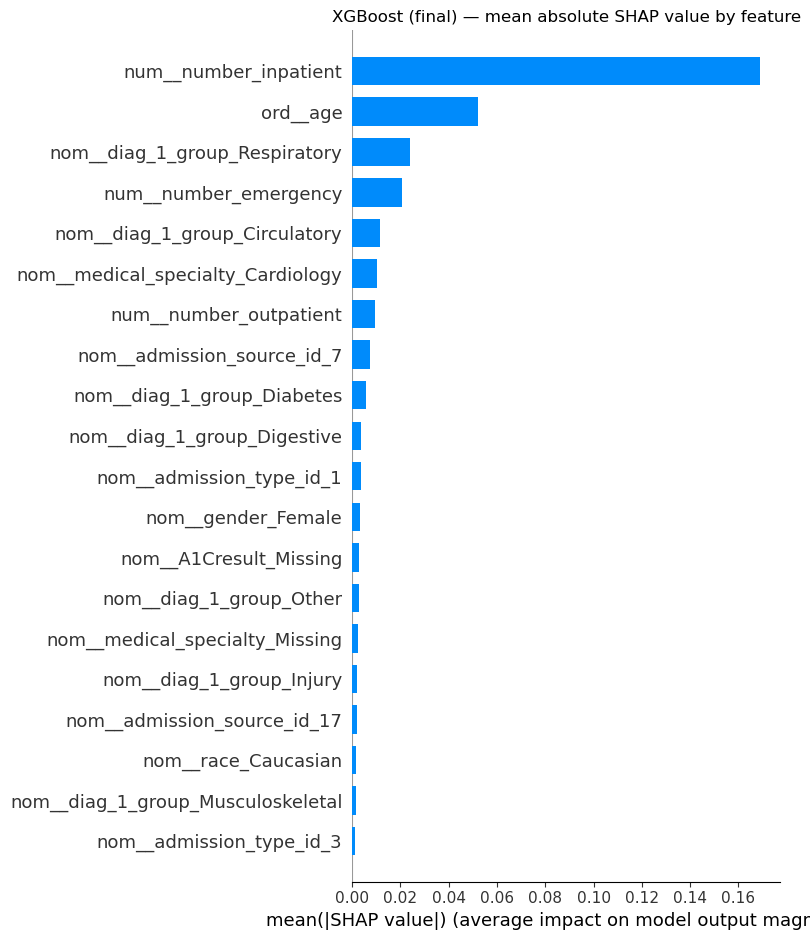

In [16]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost (final) — mean absolute SHAP value by feature")
plt.tight_layout()
plt.show()

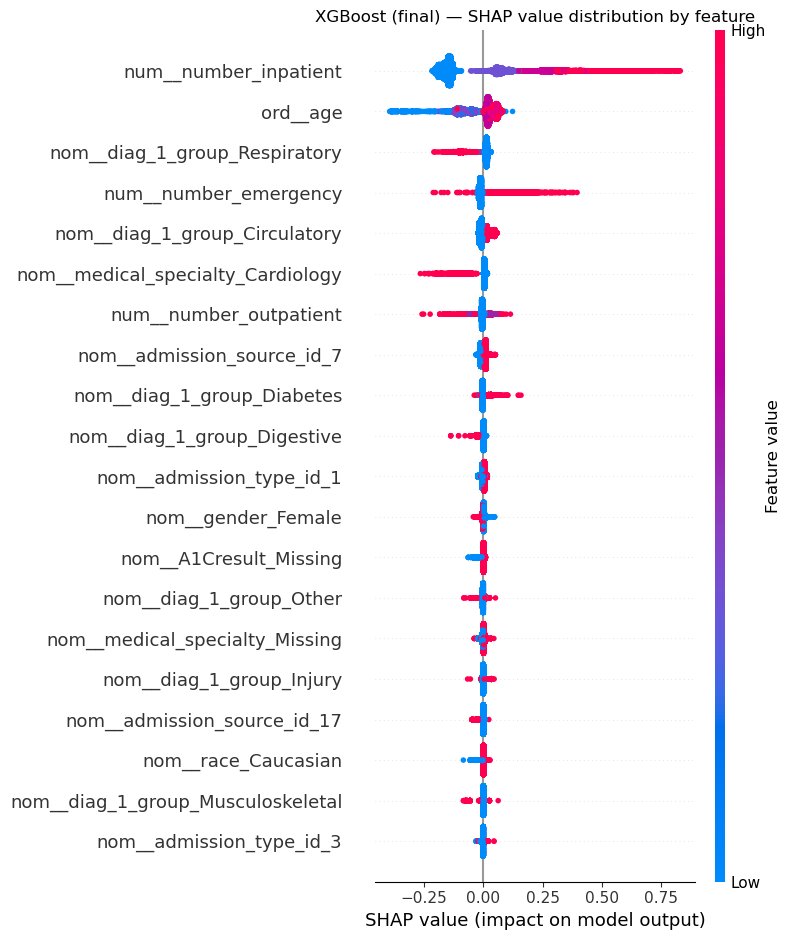

In [17]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("XGBoost (final) — SHAP value distribution by feature")
plt.tight_layout()
plt.show()

In [18]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

joblib.dump(final_model, "../models/xgboost_tuned.joblib")

results_summary = {
    "model": "XGBoost (tuned, alt config)",
    "selected_over_cv_search_winner_due_to": "search winner (n_estimators=10, lr=0.01) produced a degenerate discrete probability distribution (range 0.417-0.465); alt config gives comparable PR-AUC with a smooth, usable distribution",
    "best_params": {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v)
                     for k, v in final_params.items()},
    "chosen_threshold": float(best_threshold),
    "test_prauc": float(average_precision_score(y_test, test_proba)),
    "test_roc_auc": float(roc_auc_score(y_test, test_proba)),
    "test_precision_default": float(precision_score(y_test, test_pred_default)),
    "test_recall_default": float(recall_score(y_test, test_pred_default)),
    "test_precision_tuned": float(precision_score(y_test, test_pred_tuned)),
    "test_recall_tuned": float(recall_score(y_test, test_pred_tuned)),
    "test_f1_tuned": float(f1_score(y_test, test_pred_tuned)),
}

import json as _json
with open("../results/xgboost_tuned_summary.json", "w") as f:
    _json.dump(results_summary, f, indent=2)

print("Saved:")
print(" - ../models/xgboost_tuned.joblib")
print(" - ../results/xgboost_tuned_summary.json")
print()
print(_json.dumps(results_summary, indent=2))

Saved:
 - ../models/xgboost_tuned.joblib
 - ../results/xgboost_tuned_summary.json

{
  "model": "XGBoost (tuned, alt config)",
  "selected_over_cv_search_winner_due_to": "search winner (n_estimators=10, lr=0.01) produced a degenerate discrete probability distribution (range 0.417-0.465); alt config gives comparable PR-AUC with a smooth, usable distribution",
  "best_params": {
    "learning_rate": 0.1,
    "max_depth": 5.0,
    "min_child_weight": 1.0,
    "gamma": 0.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 7.893422057379731,
    "n_estimators": 10.0
  },
  "chosen_threshold": 0.4321323335170746,
  "test_prauc": 0.19361507921039778,
  "test_roc_auc": 0.6296977476113232,
  "test_precision_default": 0.16535804020100503,
  "test_recall_default": 0.4808219178082192,
  "test_precision_tuned": 0.1190065949735607,
  "test_recall_tuned": 0.9146118721461187,
  "test_f1_tuned": 0.21060932653383102
}
